# Clustering (et exploitation des données géographiques)

Dans cette partie nous exploitons les données géographiques et réalisons le clustering. 

Nous exportons des statistiques par commune pour croisement avec les données de vote. 

In [1]:
!pip install -r requirements.txt

In [2]:
from BDTopo_fonctions import load_gpkg
gdf=load_gpkg("Sitadel/df_clustering_fulldep_1000m3.gpkg") #BASE ENREGISTREE AVEC SEULES ADRESSES PRECISEMENT LOCALISABLES (NUM VOIE = 1/3 SITADEL)

Téléchargement depuis mgarbe/Sitadel/df_clustering_fulldep_1000m3.gpkg ...
Chargement réussi (324979 lignes)


In [3]:
gdf=gdf[((gdf["Base"]=="Sitadel") & (gdf["ind_localisable"]>0)) | (gdf["Base"]=="BDTOPO")]

In [4]:
# PC IDENTIFIABLES
gdf[gdf["Base"]=="Sitadel"].groupby("Annee_REF").size()

Annee_REF
2014    1697
2015    1762
2016    1861
2017    1756
2018    1720
2019    1627
2020    1277
2021    1501
2022    1595
2023    1319
2024    1164
2025     805
dtype: int64

In [5]:
import warnings
from sklearn.exceptions import EfficiencyWarning
warnings.filterwarnings("ignore", category=EfficiencyWarning)
import importlib
import clustering_fonctions
importlib.reload(clustering_fonctions)
from clustering_fonctions import run_dbscan_parallele
temp=run_dbscan_parallele(gdf,500,4)

Départements traités : 94/94

In [ ]:
#EXPORT DU DF 
import importlib
import os   
import BDTopo_fonctions
importlib.reload(BDTopo_fonctions)
from BDTopo_fonctions import upload_to_onyxia
#output_file = "df_POSTclustering_fulldep_1000m3.gpkg"
temp.to_file(output_file, driver="GPKG")
remote_path = f"Sitadel/{output_file}"
upload_to_onyxia(output_file, bucket="mgarbe", remote_path=remote_path)
os.remove(output_file)

[Upload] Envoi de df_POSTclustering_fulldep_1000m3.gpkg vers mgarbe/Sitadel/df_POSTclustering_fulldep_1000m3.gpkg ...
[Upload] Terminé avec succès


In [33]:
subset =temp[(temp["cluster_id_2025"]==-1) & (temp["Base"]=="Sitadel")].copy()

# Reprojection vers WGS84 (latitude / longitude)
subset = subset.to_crs(epsg=4326)

# Calcul du centroïde
subset["centroid"] = subset.geometry.centroid
subset["lat"] = subset.centroid.y
subset["lon"] = subset.centroid.x

subset[['lat','lon','SURF_CREEE','Annee_REF',"DEP_CODE"]][subset["SURF_CREEE"]>5000].sample(20)

/tmp/ipykernel_39216/1360183535.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset["centroid"] = subset.geometry.centroid
/tmp/ipykernel_39216/1360183535.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset["lat"] = subset.centroid.y
/tmp/ipykernel_39216/1360183535.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  subset["lon"] = subset.centroid.x


,lat,lon,SURF_CREEE,Annee_REF,DEP_CODE
240995,45.098967,5.720076,10766.0,2020,38
150616,49.176340,6.879225,17428.0,2018,14
314567,51.007422,2.204660,42377.0,2020,59
21250,45.386253,1.569278,5855.0,2022,19
289419,48.728801,2.362307,10780.0,2021,94
211945,48.330640,-1.203895,7958.0,2016,35
41701,48.026925,3.915575,8500.0,2019,10
115019,48.095027,0.239158,6925.0,2024,72
68675,43.931270,4.777747,11930.0,2016,30
146331,49.206522,2.119973,49642.0,2017,60


In [ ]:
# Cluster_id présents dans Sitadel
sitadel_ids = temp.loc[temp["Base"]=="Sitadel", "cluster_id_2025"].unique()

# Comptage des occurrences de tous les bâtiments pour ces cluster_id
vc = temp["cluster_id_2025"].value_counts()

# Filtrer uniquement les clusters présents dans Sitadel
vc_sitadel = vc[vc.index.isin()]

# Nombre de clusters de taille 
vc_sitadel[vc_sitadel.index > 0]sitadel_ids

cluster_id_2025
5900034    3922
9300001    3220
6900002    2386
9400001    2106
9200003    1130
           ... 
7300090       4
1200138       4
4800021       4
5900447       4
9200022       2
Name: count, Length: 4152, dtype: int64

In [38]:
# CLUSTER TOTAL, TOUS BAT EXISTANTS OU AUTORISES, ANNEE PAR ANNEE 
import pandas as pd
temp_sorted = temp.sort_values("Annee_REF")
results = []
for annee in sorted(temp_sorted["Annee_REF"].unique()):
    mask = temp_sorted["Annee_REF"] <= annee  # toutes les années <= annee
    cluster_col = temp_sorted.loc[mask, "cluster_id"]
    pct_cluster = (cluster_col > 0).sum() / len(cluster_col) * 100
    results.append({
        "Annee": annee,
        "pct_cluster_cumule": pct_cluster
    })
df_cumule = pd.DataFrame(results)
print(df_cumule)

    Annee  pct_cluster_cumule
0    2013           69.744157
1    2014           69.519815
2    2015           69.229509
3    2016           68.931352
4    2017           68.827577
5    2018           68.833133
6    2019           70.717329
7    2020           70.747871
8    2021           70.863461
9    2022           71.049322
10   2023           71.151551
11   2024           71.221765
12   2025           71.294545


In [39]:
#PC QUI EN 2025 SONT DANS UN CLUSTER
seuil=1000
temp[(temp["Base"]=="Sitadel") & (temp["SURF_CREEE"]>seuil)].groupby("Annee_REF")["cluster_id"].apply(lambda x: (x > 0).sum() / len(x) * 100)

Annee_REF
2014    84.914555
2015    86.719637
2016    86.620097
2017    87.243736
2018    89.476744
2019    87.830363
2020    88.175411
2021    90.139907
2022    90.658307
2023    89.764973
2024    87.628866
2025    87.701863
Name: cluster_id, dtype: float64

In [40]:
#PC QUI SONT DANS UN CLUSTER AU MOMENT DE AUTORISATION 

temp_sitadel = temp[(temp["Base"]=="Sitadel") & (temp["SURF_CREEE"]>seuil)]

for annee in sorted(temp_sitadel["Annee_REF"].unique()):
    col = f"cluster_id_{annee}"
    mask = temp_sitadel["Annee_REF"] == annee
    cluster_col = temp_sitadel.loc[mask, col]
    pct_cluster = (cluster_col > 0).sum() / len(cluster_col) * 100
    print(f"Année {annee}: {pct_cluster:.1f}% des bâtiments clusterisés")

Année 2014: 80.2% des bâtiments clusterisés
Année 2015: 81.4% des bâtiments clusterisés
Année 2016: 83.4% des bâtiments clusterisés
Année 2017: 84.0% des bâtiments clusterisés
Année 2018: 85.2% des bâtiments clusterisés
Année 2019: 85.8% des bâtiments clusterisés
Année 2020: 86.8% des bâtiments clusterisés
Année 2021: 88.5% des bâtiments clusterisés
Année 2022: 90.0% des bâtiments clusterisés
Année 2023: 89.1% des bâtiments clusterisés
Année 2024: 87.1% des bâtiments clusterisés
Année 2025: 87.7% des bâtiments clusterisés


In [41]:
annees = sorted(temp["Annee_REF"].unique())
result_list = []
for annee in annees:
    col = f"cluster_id_{annee}"
    if col in temp.columns:
        # compter les clusters uniques non-négatifs
        nb_clusters = temp[col][temp[col] > 0].nunique()
        result_list.append({"Annee_REF": annee, "nb_clusters": nb_clusters})

df_clusters_par_annee = pd.DataFrame(result_list)
print(df_clusters_par_annee)

    Annee_REF  nb_clusters
0        2013         8533
1        2014         8833
2        2015         9053
3        2016         9276
4        2017         9466
5        2018         9582
6        2019        11113
7        2020        11328
8        2021        11388
9        2022        11506
10       2023        11562
11       2024        11669
12       2025        11743


In [52]:
# Paramètres
annees_plot = sorted(temp["Annee_REF"].unique())
annees_plot = [annee for annee in annees_plot if annee >= 2014]

result_list = []

for annee in annees_plot:
    col = f"cluster_id_{annee}"
    if col not in temp.columns:
        continue
    
    # Cluster_id présents dans Sitadel
    sitadel_ids = temp.loc[temp["Base"]=="Sitadel", col].unique()
    
    # Comptage des occurrences de tous les bâtiments pour ces cluster_id
    vc = temp[col].value_counts()
    
    # Filtrer uniquement les clusters auxquels appartient Sitadel et cluster_id > 0
    vc_sitadel = vc[(vc.index.isin(sitadel_ids)) & (vc.index > 0)]
    
    # Taille moyenne des clusters valides
    mean_size = vc_sitadel.mean() if len(vc_sitadel) > 0 else 0
    
    result_list.append({"Annee_REF": annee, "taille_moyenne_cluster": mean_size})

df_cluster_sizes = pd.DataFrame(result_list)
print(df_cluster_sizes)


    Annee_REF  taille_moyenne_cluster
0        2014               74.086354
1        2015               59.030779
2        2016               50.988676
3        2017               46.619678
4        2018               43.982281
5        2019               44.153846
6        2020               42.849027
7        2021               41.460671
8        2022               40.398806
9        2023               39.421406
10       2024               38.531952
11       2025               38.202553


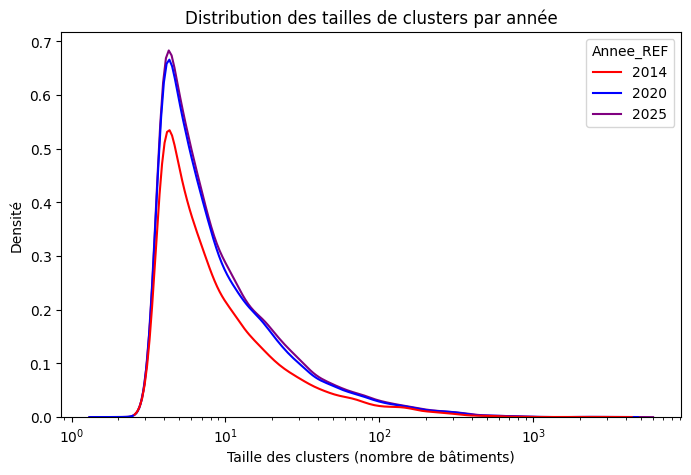

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Les années à visualiser
annees_plot = [2014, 2020, 2025]

# Créer un DataFrame “long” pour seaborn
plot_data = []

for annee in annees_plot:
    col = f"cluster_id_{annee}"
    if col not in temp.columns:
        continue
    cluster_sizes = temp[temp[col] > 0].groupby(col).size()
    for size in cluster_sizes:
        plot_data.append({"Annee_REF": annee, "cluster_size": size})

df_plot = pd.DataFrame(plot_data)

# Palette personnalisée : rouge, bleu, violet
palette_colors = {2014: "red", 2020: "blue", 2025: "purple"}

# Tracer les distributions
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df_plot,
    x="cluster_size",
    hue="Annee_REF",
    log_scale=True,
    palette=palette_colors
)
plt.xlabel("Taille des clusters (nombre de bâtiments)")
plt.ylabel("Densité")
plt.title("Distribution des tailles de clusters par année")
plt.show()
